# 공유오피스 3일 체험 결제 전환 예측 모델링 보고서

## 분석 목적

이 노트북에서는 공유오피스 3일 체험 신청자의 신청, 방문, 출입, 결제 데이터를 활용하여 **체험 이후 결제 전환 여부를 예측해 추후에 마케팅에 활용할 XGBoost 분류 모델**을 구축하는 과정을 정리했습니다.

## 목차

```text
데이터 로드
→ 데이터 구조 확인
→ 전처리
→ EDA
→ 피처 엔지니어링
→ Train / Valid / Test 분할
→ XGBoost 모델 학습
→ Threshold 비교
→ Ablation Test
→ 전체 피처 조합 비교
→ 최종 모델 재학습
→ Test 최종 평가
→ Feature Importance / Permutation Importance 확인
→ 모델 오류 분석
→ Streamlit 배포용 파일 저장
```

## 모델링 기준

- **Target**: `is_payment` — 결제 전환 여부
- **Model**: XGBoost Classifier
- **Validation 기준**: F1 Score 중심, Recall과 Precision 함께 확인
- **Test 기준**: 최종 선택된 피처와 threshold를 고정한 뒤 한 번만 평가

> 결제 전환 예측은 결제 가능성이 있는 고객을 넓게 포착하는 목적이 있으므로 Recall이 가장 중요하다고 생각했다. 다만 Recall만 높이면 미결제 고객까지 과도하게 결제 예상으로 분류할 수 있으므로 Precision 값과 Recall을 함께 고려해 평가하는 F1 Score를 함께 기준으로 사용하였다.

# 1. 환경설정 및 데이터 로드

분석에 필요한 라이브러리를 불러오고 Google Drive에 저장된 원천 CSV 파일을 `gdown`으로 받아 읽어온다.

- `trial_register.csv`: 3일 체험 신청 정보
- `trial_visit_info.csv`: 방문 정보
- `trial_access_log.csv`: 출입 로그
- `trial_payment.csv`: 결제 여부
- `site_area.csv`: 지점 면적 정보

In [31]:
!pip install -q gdown koreanize-matplotlib
!pip install -q streamlit xgboost joblib pandas seaborn statsmodels

In [32]:
from pathlib import Path
import warnings
import platform

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# =========================
# 한글 폰트 설정
# =========================

try:
    import koreanize_matplotlib
except Exception:
    pass

if platform.system() == 'Darwin':      # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':   # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:                                  # Linux / Colab
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 0
BLUE = '#2563eb'

# =========================
# Google Drive 파일 다운로드
# =========================

files = {
    "site_area.csv": "1tqjCywUBX7ivID62rDJ19ZchQmkLmCmr",
    "trial_access_log.csv": "17_VUATpRUGn7wcmkUkUcFmUQmkA9S0wb",
    "trial_payment.csv": "1OM2pDtVaq6vG-JcoilOunfETUtdLeZWN",
    "trial_register.csv": "1zbjXQMB6jJzJa0seEL0jUwuiRCYGQXFl",
    "trial_visit_info.csv": "1-hNqJ1aoHfqaDJV-WaLsXvf6nk_BNUD0"
}

for filename, file_id in files.items():
    file_path = Path(filename)

    if file_path.exists():
        print(f"이미 존재: {filename}")
    else:
        print(f"다운로드 중: {filename}")
        gdown.download(
            f"https://drive.google.com/uc?id={file_id}",
            filename,
            quiet=False
        )

# =========================
# 데이터 로드
# =========================

area_df = pd.read_csv('site_area.csv')
access_log_df = pd.read_csv('trial_access_log.csv')
payment_log_df = pd.read_csv('trial_payment.csv')
register_df = pd.read_csv('trial_register.csv')
visit_info_df = pd.read_csv('trial_visit_info.csv')

print('데이터 로드 완료')
print('site_area:', area_df.shape)
print('access_log:', access_log_df.shape)
print('payment_log:', payment_log_df.shape)
print('register:', register_df.shape)
print('visit_info:', visit_info_df.shape)

이미 존재: site_area.csv
이미 존재: trial_access_log.csv
이미 존재: trial_payment.csv
이미 존재: trial_register.csv
이미 존재: trial_visit_info.csv
데이터 로드 완료
site_area: (9, 2)
access_log: (63708, 5)
payment_log: (9659, 2)
register: (9659, 2)
visit_info: (11477, 7)


# 2. 데이터 구조 확인

각 데이터셋의 행/열 수와 컬럼 타입, 중복 여부를 모델링 전에 살펴본다.

In [33]:
for name, data in [
    ('trial_register', register_df),
    ('trial_visit_info', visit_info_df),
    ('trial_access_log', access_log_df),
    ('trial_payment', payment_log_df),
    ('site_area', area_df),
]:
    print(f'\n{name}')
    print('-' * 60)
    print('shape:', data.shape)
    print('duplicated rows:', data.duplicated().sum())
    display(data.head())
    print(data.dtypes)



trial_register
------------------------------------------------------------
shape: (9659, 2)
duplicated rows: 28


,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0


trial_date    object
user_uuid     object
dtype: object

trial_visit_info
------------------------------------------------------------
shape: (11477, 7)
duplicated rows: 48


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594


site_id              int64
date                object
stay_time           object
stay_time_second     int64
first_enter_time    object
last_leave_time     object
user_uuid           object
dtype: object

trial_access_log
------------------------------------------------------------
shape: (63708, 5)
duplicated rows: 359


...

id            int64
checkin       int64
cdate        object
site_id       int64
user_uuid    object
dtype: object

trial_payment
------------------------------------------------------------
shape: (9659, 2)
duplicated rows: 35


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0


is_payment     int64
user_uuid     object
dtype: object

site_area
------------------------------------------------------------
shape: (9, 2)
duplicated rows: 0


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150
3,4,100
4,5,150


site_id        int64
area_pyeong    int64
dtype: object


# 3. 데이터 전처리

전처리 기준은 다음과 같다.

1. 각 원천 테이블의 완전 중복 행 제거
2. `register_df`에서 동일 `user_uuid`가 여러 번 존재하면 신청일 기준 최신 행 유지
3. 날짜 및 시간 컬럼 타입 변환
4. `visit_info_df`의 입실/퇴실 결측값을 `access_log_df` 기준으로 보강
5. `visit_info_df`와 `access_log_df` 중 한쪽에만 존재하는 `user_uuid`는 분석 대상에서 제외

## 3-1. 중복 제거

중복이 있으면 방문일수, 출입횟수, 결제 정보 집계가 중복 반영될 수 있어 완전히 동일한 중복 행은 제거한다.

In [34]:
access_log_df = access_log_df.drop_duplicates(keep='last')
visit_info_df = visit_info_df.drop_duplicates(keep='last')
payment_log_df = payment_log_df.drop_duplicates(keep='last')
register_df = register_df.drop_duplicates(keep='last')

print(access_log_df.shape, visit_info_df.shape, payment_log_df.shape, register_df.shape)


(63349, 5) (11429, 7) (9624, 2) (9631, 2)


## 3-2. 모수 설정 — register 기준, user_uuid 중복은 최신 데이터만 유지

신청 테이블인 `register_df`에서 동일 유저가 여러 번 존재할 수 있으므로 신청일 기준 최신 기록만 유지한다.

아직 다른 테이블을 `register_df` 기준으로 필터링하지는 않는다. 기존 기준 노트북에서는 이후 `visit_info_df`와 `access_log_df`의 유저 불일치를 제거하면서 모든 테이블의 분석 대상을 맞췄다.

In [35]:
register_df = register_df.sort_values('trial_date').drop_duplicates(subset=['user_uuid'], keep='last')
print('모수:', register_df.shape, payment_log_df.shape)


모수: (9624, 2) (9624, 2)


## 3-3. datetime 타입 변환

신청일, 출입 로그 시간, 방문 입실/퇴실 시간, 방문일을 분석 가능한 datetime 타입으로 변환한다.

`access_log_df['cdate']`는 UTC 기준으로 읽은 뒤 `Asia/Seoul` 시간대로 변환한다. 이후 `visit_info_df`의 결측 입실/퇴실 시간을 보강할 때 같은 날짜 단위로 매칭하기 위해 사용한다.

In [36]:
register_df['trial_date'] = pd.to_datetime(register_df['trial_date'])

access_log_df['cdate'] = pd.to_datetime(access_log_df['cdate'], utc=True).dt.tz_convert('Asia/Seoul')
access_log_df['cdate'] = pd.to_datetime(access_log_df['cdate']).dt.floor('s')

visit_info_df['first_enter_time'] = pd.to_datetime(visit_info_df['first_enter_time'], format='%Y-%m-%d %H:%M:%S', exact=False).dt.floor('s')
visit_info_df['last_leave_time'] = pd.to_datetime(visit_info_df['last_leave_time'], format='%Y-%m-%d %H:%M:%S', exact=False).dt.floor('s')
visit_info_df['stay_time'] = pd.to_timedelta(visit_info_df['stay_time']).dt.floor('s')
visit_info_df['date'] = pd.to_datetime(visit_info_df['date'])


## 3-4. `visit_info` 결측값을 `access_log`로 보강

`visit_info_df`에 입실/퇴실 시간이 비어 있는 경우 `access_log_df`의 실제 출입 기록으로 보강한다.

- 입실 시간: 같은 유저, 같은 날짜의 `checkin == 1` 중 가장 빠른 시간
- 퇴실 시간: 같은 유저, 같은 날짜의 `checkin == 2` 중 가장 늦은 시간

In [37]:
access_log_df['date'] = access_log_df['cdate'].dt.date.astype('datetime64[ns]')
access_log_df['cdate_naive'] = access_log_df['cdate'].dt.tz_localize(None)

access_first_enter = (access_log_df[access_log_df['checkin'] == 1]
    .groupby(['user_uuid', 'date'])['cdate_naive'].min().reset_index()
    .rename(columns={'cdate_naive': 'new_first_enter_time'}))

access_last_leave = (access_log_df[access_log_df['checkin'] == 2]
    .groupby(['user_uuid', 'date'])['cdate_naive'].max().reset_index()
    .rename(columns={'cdate_naive': 'new_last_leave_time'}))

visit_info_df = visit_info_df.merge(access_first_enter, on=['user_uuid', 'date'], how='left')
visit_info_df = visit_info_df.merge(access_last_leave, on=['user_uuid', 'date'], how='left')

visit_info_df['first_enter_time'] = visit_info_df['first_enter_time'].fillna(visit_info_df['new_first_enter_time'])
visit_info_df['last_leave_time'] = visit_info_df['last_leave_time'].fillna(visit_info_df['new_last_leave_time'])

visit_info_df = visit_info_df.drop(columns=['new_first_enter_time', 'new_last_leave_time'])
access_log_df = access_log_df.drop(columns=['date', 'cdate_naive'])

print(visit_info_df['first_enter_time'].isnull().sum(), visit_info_df['last_leave_time'].isnull().sum())


75 72


## 3-5. `visit_info` ↔ `access_log` 간 user_uuid 불일치 제거

`visit_info_df`와 `access_log_df` 중 한쪽에만 존재하는 유저를 분석 대상에서 제외했다.

이 처리는 방문 정보와 출입 로그를 함께 사용하는 피처(`방문일수`, `총출입횟수`, `신청후첫방문일수`, `방문당체류시간`)의 기준을 맞추기 위한 작업이다.

In [38]:
visit_only_uuids = set(visit_info_df['user_uuid'].unique()) - set(access_log_df['user_uuid'].unique())
access_only_uuids = set(access_log_df['user_uuid'].unique()) - set(visit_info_df['user_uuid'].unique())
uuids_to_remove = visit_only_uuids.union(access_only_uuids)

access_log_df = access_log_df[~access_log_df['user_uuid'].isin(uuids_to_remove)]
visit_info_df = visit_info_df[~visit_info_df['user_uuid'].isin(uuids_to_remove)]
payment_log_df = payment_log_df[~payment_log_df['user_uuid'].isin(uuids_to_remove)]
register_df = register_df[~register_df['user_uuid'].isin(uuids_to_remove)]

print('제거된 user_uuid 수:', len(uuids_to_remove))
print('각 df user_uuid 수:', access_log_df['user_uuid'].nunique(), visit_info_df['user_uuid'].nunique(),
      payment_log_df['user_uuid'].nunique(), register_df['user_uuid'].nunique())


제거된 user_uuid 수: 514
각 df user_uuid 수: 6023 6023 9110 9110


# 4. EDA: 모델링 전 주요 패턴 확인

EDA는 모델링 전에 데이터의 방향성을 확인하는 단계이고, 여기서는 분석에 꼭 필요한 수준으로만 정리하였다.


1. 결제자 / 미결제자 비율
2. 신청 추이
3. 방문일수별 결제율
4. 결제자와 미결제자의 방문 행동 차이

> EDA 결과는 모델 해석의 배경으로 사용한다. 최종 피처 선택은 EDA가 아니라 Train/Valid 분할 이후 Valid 성능 기준으로 진행한다.

## 4-1. 결제자 / 미결제자 비율

Target인 `is_payment`의 클래스 비율부터 본다. 결제자 비율이 낮으면 모델이 미결제 쪽으로 치우칠 수 있으므로 이후 XGBoost 파라미터 조정에서 `scale_pos_weight`를 적용한다.

,user_count
is_payment,
미결제,5685
결제,3425


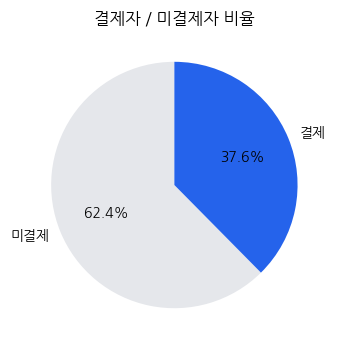

In [39]:
payment_label = (
    payment_log_df[['user_uuid', 'is_payment']]
    .drop_duplicates('user_uuid')
    .copy()
)
payment_label['is_payment'] = payment_label['is_payment'].fillna(0).astype(int)

payment_rate_df = (
    register_df[['user_uuid']]
    .merge(payment_label, on='user_uuid', how='left')
)
payment_rate_df['is_payment'] = payment_rate_df['is_payment'].fillna(0).astype(int)

payment_summary = payment_rate_df['is_payment'].value_counts().rename(index={0: '미결제', 1: '결제'})
display(payment_summary.to_frame('user_count'))

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(
    payment_summary.values,
    labels=payment_summary.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#e5e7eb', BLUE],
)
ax.set_title('결제자 / 미결제자 비율')
plt.show()


## 4-2. 신청 추이

신청일 기준 월별 신청자 수 추이를 본다.

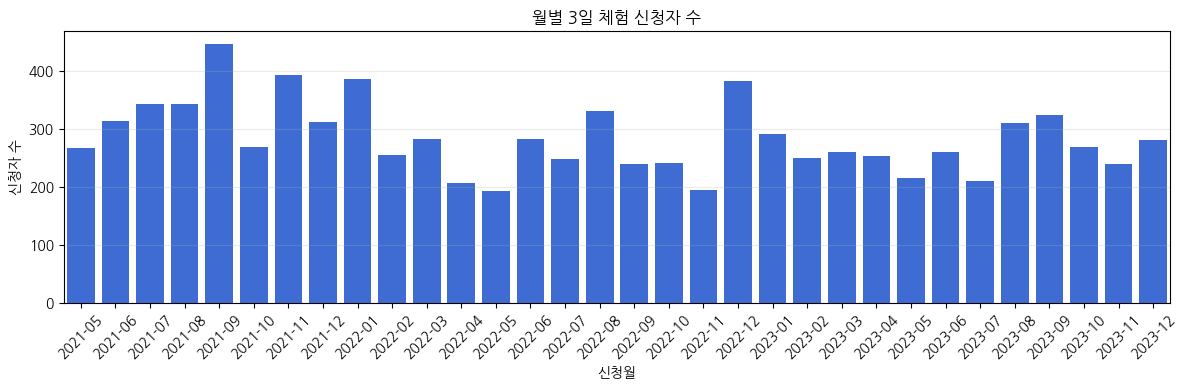

In [40]:
register_df['trial_month'] = register_df['trial_date'].dt.to_period('M').astype(str)
monthly_register = (
    register_df
    .groupby('trial_month')['user_uuid']
    .nunique()
    .reset_index(name='신청자수')
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=monthly_register, x='trial_month', y='신청자수', color=BLUE, ax=ax)
ax.set_title('월별 3일 체험 신청자 수')
ax.set_xlabel('신청월')
ax.set_ylabel('신청자 수')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## 4-3. 방문일수별 결제율

방문일수는 최종 모델의 주요 후보 피처여서 방문일수가 늘어날수록 결제율이 어떻게 달라지는지 함께 본다.

,방문일수,count,sum,결제율
0,0,3087,1088,35.244574
1,1,2709,849,31.339978
2,2,1932,811,41.977226
3,3,1382,677,48.986975


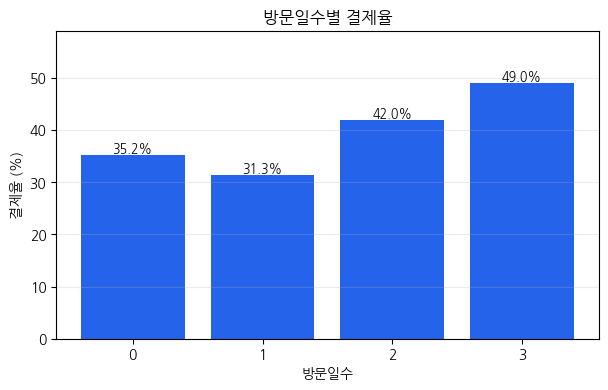

In [41]:
visit_days_eda = (
    visit_info_df
    .groupby('user_uuid')['date']
    .nunique()
    .reset_index(name='방문일수')
)

visit_payment_eda = (
    register_df[['user_uuid']]
    .merge(visit_days_eda, on='user_uuid', how='left')
    .merge(payment_label, on='user_uuid', how='left')
)

visit_payment_eda['방문일수'] = visit_payment_eda['방문일수'].fillna(0).astype(int)
visit_payment_eda['방문일수'] = visit_payment_eda['방문일수'].clip(upper=3)   # 4일 이상은 3일로 묶기
visit_payment_eda['is_payment'] = visit_payment_eda['is_payment'].fillna(0).astype(int)

visit_rate = (
    visit_payment_eda
    .groupby('방문일수')['is_payment']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)
visit_rate['결제율'] = visit_rate['mean'] * 100

display(visit_rate[['방문일수', 'count', 'sum', '결제율']])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(visit_rate['방문일수'].astype(str), visit_rate['결제율'], color=BLUE)

for bar, val in zip(bars, visit_rate['결제율']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

ax.set_title('방문일수별 결제율')
ax.set_xlabel('방문일수')
ax.set_ylabel('결제율 (%)')
ax.set_ylim(0, max(visit_rate['결제율'].max() + 10, 10))
ax.grid(axis='y', alpha=0.25)
plt.show()

무료체험 기간인 3일간의 데이터 중에 4일 방문한 데이터는 3일 방문한 고객 수에 포함했다.

## 4-4. 결제자 vs 미결제자 행동 비교

모델 후보 피처로 쓸 방문일수, 총출입횟수, 신청 후 첫방문까지 걸린 일수의 평균 차이를 본다.

,방문일수,총출입횟수,신청후첫방문일수
is_payment,,,
미결제,1.10,6.83,0.22
결제,1.33,7.15,0.31


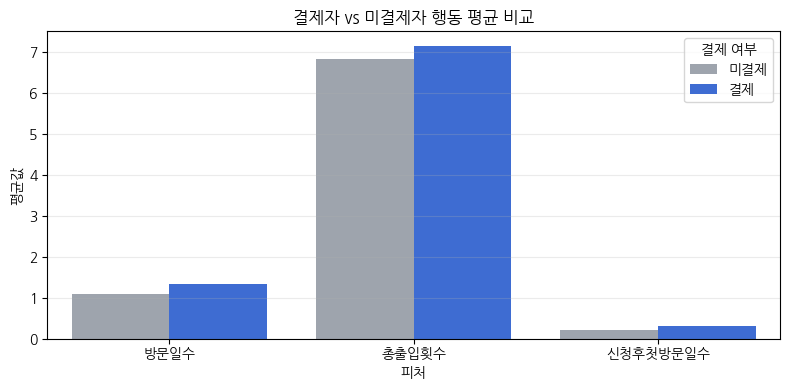

In [42]:
# 사용자별 총 출입횟수
access_count_eda = (
    access_log_df
    .groupby('user_uuid')
    .size()
    .reset_index(name='총출입횟수')
)

# 첫 방문일
visit_sorted_eda = visit_info_df.sort_values(['user_uuid', 'date']).copy()
first_visit_eda = (
    visit_sorted_eda
    .dropna(subset=['date'])
    .groupby('user_uuid', as_index=False)['date']
    .min()
    .rename(columns={'date': '첫방문일'})
)

first_visit_gap_eda = register_df[['user_uuid', 'trial_date']].merge(first_visit_eda, on='user_uuid', how='left')
first_visit_gap_eda['신청후첫방문일수'] = (
    first_visit_gap_eda['첫방문일'] - first_visit_gap_eda['trial_date']
).dt.days
first_visit_gap_eda['신청후첫방문일수'] = first_visit_gap_eda['신청후첫방문일수'].clip(lower=0)

behavior_eda = (
    register_df[['user_uuid']]
    .merge(visit_days_eda, on='user_uuid', how='left')
    .merge(access_count_eda, on='user_uuid', how='left')
    .merge(first_visit_gap_eda[['user_uuid', '신청후첫방문일수']], on='user_uuid', how='left')
    .merge(payment_label, on='user_uuid', how='left')
)
behavior_eda['방문일수'] = behavior_eda['방문일수'].fillna(0)
behavior_eda['총출입횟수'] = behavior_eda['총출입횟수'].fillna(0)
behavior_eda['신청후첫방문일수'] = behavior_eda['신청후첫방문일수'].fillna(-1)
behavior_eda['is_payment'] = behavior_eda['is_payment'].fillna(0).astype(int)

compare_cols = ['방문일수', '총출입횟수', '신청후첫방문일수']
compare_df = behavior_eda.groupby('is_payment')[compare_cols].mean().rename(index={0: '미결제', 1: '결제'}).round(2)
display(compare_df)

plot_df = compare_df.reset_index().melt(id_vars='is_payment', var_name='피처', value_name='평균값')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='피처', y='평균값', hue='is_payment', palette=['#9ca3af', BLUE], ax=ax)
ax.set_title('결제자 vs 미결제자 행동 평균 비교')
ax.set_xlabel('피처')
ax.set_ylabel('평균값')
ax.legend(title='결제 여부')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


# 5. 피처 엔지니어링

모델 학습용 유저 단위 데이터프레임 `feature_df`를 생성한다. 앞선 전처리에서 `visit_info_df`와 `access_log_df`의 유저 기준을 맞춘 뒤 아래 방식으로 피처를 만든다.

- `register_df`의 신청 유저를 기준으로 피처 테이블 생성
- 방문일수는 `visit_info_df`의 유저별 고유 방문일 수로 계산
- 체류시간은 `stay_time_second`를 시간 단위로 변환한 뒤 집계
- 출입횟수는 `access_log_df`의 유저별 로그 수로 계산
- 미방문 또는 로그가 없는 경우 기본 결측값은 `-1`로 처리
- 결제 정보가 없는 유저는 미결제로 처리
- `방문당체류시간`은 방문일수가 1 이상일 때만 계산하고 미방문자는 `-1`로 처리

후보 피처는 총 9개이다.

- `신청요일`
- `방문일수`
- `일평균체류시간`
- `총체류시간`
- `총출입횟수`
- `주말방문포함`
- `신청후첫방문일수`
- `방문여부`
- `방문당체류시간`

`방문당체류시간`은 기존 피처를 바탕으로 추가한 파생 피처이다.

In [43]:
# =========================
# 피처 엔지니어링에 필요한 중간 변수 생성
# =========================

# 방문 회차 계산
visit_info_df_sorted = visit_info_df.sort_values(['user_uuid', 'date']).copy()
visit_info_df_sorted['visit_day_number'] = (
    visit_info_df_sorted
    .groupby('user_uuid')
    .cumcount() + 1
)

# 첫 방문일 계산
first_visit = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] == 1]
    [['user_uuid', 'first_enter_time']]
    .copy()
)

first_visit['첫방문일'] = pd.to_datetime(
    first_visit['first_enter_time']
).dt.normalize()

# 신청 후 첫 방문까지 걸린 일수
days_to_first = register_df[['user_uuid', 'trial_date']].merge(
    first_visit,
    on='user_uuid',
    how='left'
)

days_to_first['신청후첫방문일수'] = (
    days_to_first['첫방문일'] - days_to_first['trial_date']
).dt.days.clip(lower=0)

days_to_first = days_to_first[['user_uuid', '신청후첫방문일수']]

# 결제 라벨
payment_label = (
    payment_log_df[['user_uuid', 'is_payment']]
    .drop_duplicates('user_uuid')
)

# =========================
# 유저 단위 feature_df 생성
# =========================

visit_info_df['stay_time_hours'] = visit_info_df['stay_time_second'] / 3600

# 방문일수
visit_days = visit_info_df.groupby('user_uuid')['date'].nunique().reset_index(name='방문일수')

# 체류시간
stay = (visit_info_df.groupby('user_uuid')['stay_time_hours']
    .agg(일평균체류시간='mean', 총체류시간='sum').round(2).reset_index())

# 출입횟수
access_total = access_log_df.groupby('user_uuid').size().reset_index(name='총출입횟수')

# 신청요일
register_feat = register_df[['user_uuid', 'trial_date']].copy()
register_feat['신청요일'] = register_feat['trial_date'].dt.dayofweek

# 주말방문포함
visit_info_df_sorted['요일'] = pd.to_datetime(visit_info_df_sorted['date']).dt.dayofweek
weekend_visit = (visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]
    .groupby('user_uuid')['요일'].apply(lambda x: int((x >= 5).any()))
    .reset_index(name='주말방문포함'))

# 신청후첫방문일수
# 위에서 계산한 days_to_first를 재사용
days_to_first_feat = days_to_first[['user_uuid', '신청후첫방문일수']]

# 병합
feature_df = register_feat[['user_uuid', '신청요일']]
for df_part in [visit_days, stay, access_total, weekend_visit, days_to_first_feat]:
    feature_df = feature_df.merge(df_part, on='user_uuid', how='left')

feature_df['방문여부'] = np.where(feature_df['신청후첫방문일수'].notna(), 1, 0)
feature_df = feature_df.fillna(-1)

# is_payment 라벨 병합
feature_df = feature_df.merge(payment_label, on='user_uuid', how='left')

# 결제 정보가 없는 유저는 미결제로 처리
feature_df['is_payment'] = feature_df['is_payment'].fillna(0).astype(int)

# 방문당체류시간
# 방문일수가 1 이상인 경우에만 계산
# 미방문자는 -1로 처리
feature_df['방문당체류시간'] = np.where(
    feature_df['방문일수'] > 0,
    feature_df['총체류시간'] / feature_df['방문일수'],
    -1
)

feature_df['방문당체류시간'] = (
    feature_df['방문당체류시간']
    .replace([np.inf, -np.inf], -1)
    .fillna(-1)
)

print(feature_df.shape)
display(feature_df.head())


(9110, 11)


,user_uuid,신청요일,방문일수,일평균체류시간,총체류시간,총출입횟수,주말방문포함,신청후첫방문일수,방문여부,is_payment,방문당체류시간
0,badbde4d-886b-4992-a8e3-fd0c05640183,5,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,0,1,-1.00
1,e079e682-62f2-4c05-84b9-86913e3dc146,5,1.0,2.75,2.75,6.0,1.0,1.0,1,0,2.75
2,f25078d1-1030-485c-85c5-dc82d6987043,5,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,0,1,-1.00
3,844319ff-cd15-4633-9900-6eaf4dc68b68,5,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,0,1,-1.00
4,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,5,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,0,1,-1.00


## 5-1. 최종 후보 피처 정의

모델링에 사용할 후보 피처를 명시적으로 고정해 이후 Train/Valid/Test 분할과 Ablation Test, 전체 피처 조합 비교가 모두 이 리스트를 기준으로 돌아가게 한다.

In [44]:
feature_candidates = [
    '신청요일',
    '방문일수',
    '일평균체류시간',
    '총체류시간',
    '총출입횟수',
    '주말방문포함',
    '신청후첫방문일수',
    '방문여부',
    '방문당체류시간'
]

target_col = 'is_payment'

print('후보 피처 수:', len(feature_candidates))
print(feature_candidates)


후보 피처 수: 9
['신청요일', '방문일수', '일평균체류시간', '총체류시간', '총출입횟수', '주말방문포함', '신청후첫방문일수', '방문여부', '방문당체류시간']


## 5-2. 피처 상태 확인

후보 피처의 결측치와 데이터 타입, 기본 통계량을 모델링 전에 점검한다.

In [45]:
print('후보 피처 결측치')
display(feature_df[feature_candidates + [target_col]].isna().sum().to_frame('missing_count'))

print('후보 피처 기술통계')
display(feature_df[feature_candidates].describe().T)


후보 피처 결측치


,missing_count
신청요일,0
방문일수,0
일평균체류시간,0
총체류시간,0
총출입횟수,0
주말방문포함,0
신청후첫방문일수,0
방문여부,0
방문당체류시간,0
is_payment,0


후보 피처 기술통계


,count,mean,std,min,25%,50%,75%,max
신청요일,9110.0,2.398353,1.898552,0.0,1.0,2.00,4.0000,6.00
방문일수,9110.0,0.847091,1.482507,-1.0,-1.0,1.00,2.0000,4.00
일평균체류시간,9110.0,2.615371,3.509225,-1.0,-1.0,2.27,4.9475,23.30
총체류시간,9110.0,5.280476,7.377601,-1.0,-1.0,3.04,8.6100,69.22
총출입횟수,9110.0,6.611745,9.230652,-1.0,-1.0,4.00,10.0000,80.00
주말방문포함,9110.0,-0.139078,0.720662,-1.0,-1.0,0.00,0.0000,1.00
신청후첫방문일수,9110.0,0.250055,1.042956,-1.0,-1.0,0.00,1.0000,2.00
방문여부,9110.0,0.660703,0.473497,0.0,0.0,1.00,1.0000,1.00
방문당체류시간,9110.0,2.635509,3.532045,-1.0,-1.0,2.30,4.9800,23.30


## 5-3. 상관관계 및 VIF 확인

상관관계와 VIF는 피처 간 중복 정보를 파악하기 위한 참고용이다.

단, 본 프로젝트의 최종 모델인 XGBoost는 트리 기반 모델이므로 선형 모델보다 다중공선성에 덜 민감하다. VIF 결과만으로 피처를 제거하지 않고 최종 피처 선택은 Valid 성능 기준으로 진행한다.

,target_corr
방문일수,0.089081
신청후첫방문일수,0.040975
방문여부,0.035464
주말방문포함,0.033757
총출입횟수,0.018163
총체류시간,0.016537
신청요일,-0.020336
일평균체류시간,-0.029841
방문당체류시간,-0.030077


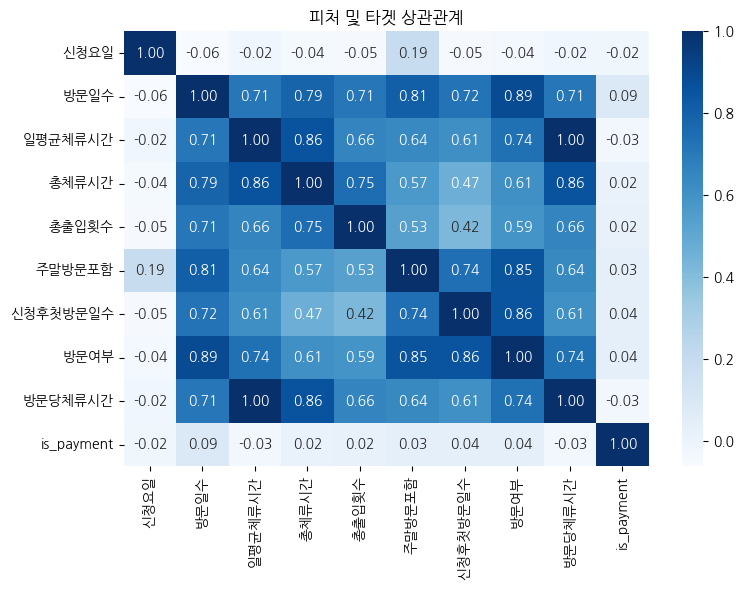

In [46]:
# 피처-타겟 상관관계
corr_with_target = (
    feature_df[feature_candidates + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

display(corr_with_target.to_frame('target_corr'))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    feature_df[feature_candidates + [target_col]].corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=ax,
)
ax.set_title('피처 및 타겟 상관관계')
plt.tight_layout()
plt.show()


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_input = feature_df[feature_candidates].replace([np.inf, -np.inf], np.nan).fillna(0)
vif_df = pd.DataFrame({
    'feature': feature_candidates,
    'VIF': [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])]
}).sort_values('VIF', ascending=False)
display(vif_df)

,feature,VIF
8,방문당체류시간,282.015523
2,일평균체류시간,279.208928
1,방문일수,18.972230
3,총체류시간,17.043825
7,방문여부,16.155846
4,총출입횟수,3.867086
6,신청후첫방문일수,3.782514
5,주말방문포함,3.366994
0,신청요일,2.620285


# 6. Train / Valid / Test 분할

데이터는 Train / Valid / Test로 나눈다.

- **Train**: 모델 학습
- **Valid**: threshold 선택, ablation test, 피처 조합 비교
- **Test**: 최종 선택된 모델을 마지막으로 평가

## 분할 기준

- 1차 분리: Train+Valid 80%, Test 20%
- 2차 분리: Train 60%, Valid 20%
- `random_state=0`
- `stratify=y` 적용

`stratify=y`를 사용하면 결제자/미결제자 비율이 각 데이터셋에 비슷하게 유지된다.

In [48]:
from sklearn.model_selection import train_test_split

X = feature_df[feature_candidates]
y = feature_df[target_col]

# 1차 분리: train_valid 80%, test 20%
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

# 2차 분리: train 60%, valid 20%
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.25,
    random_state=0,
    stratify=y_train_valid
)

print('Train:', X_train.shape)
print('Valid:', X_valid.shape)
print('Test:', X_test.shape)

print('Train 결제율:', round(y_train.mean(), 3))
print('Valid 결제율:', round(y_valid.mean(), 3))
print('Test 결제율:', round(y_test.mean(), 3))


Train: (5466, 9)
Valid: (1822, 9)
Test: (1822, 9)
Train 결제율: 0.376
Valid 결제율: 0.376
Test 결제율: 0.376


# 7. XGBoost 모델 학습 및 Threshold 비교

XGBoost 모델을 사용한 이유는 다음과 같다.

1. 비선형 관계를 잘 포착할 수 있다.
2. 방문일수, 총출입횟수, 체류시간처럼 분포가 치우친 피처에도 비교적 강하다.
3. Feature Importance를 통해 모델 해석이 가능하다.
4. 결제/미결제 비율이 불균형한 경우 `scale_pos_weight`를 적용할 수 있다.

먼저 전체 후보 피처 9개를 모두 사용하여 XGBoost 모델을 학습하고 Valid 데이터에서 threshold별 성능을 본다.

## 7-1. XGBoost 모델 함수 생성

Ablation Test와 전체 피처 조합 비교에서는 모델을 여러 번 반복 학습해야 한다. 매번 같은 설정의 XGBoost 모델을 만들 수 있도록 함수로 분리한 이유다.

`scale_pos_weight`는 미결제자와 결제자의 비율 차이를 반영하기 위한 값이다. 결제자가 소수 클래스인 경우 결제자를 더 신경 쓰도록 학습시키는 효과가 있다.

In [49]:
from xgboost import XGBClassifier

def make_xgb_model(y_train_data):
    neg_count = (y_train_data == 0).sum()
    pos_count = (y_train_data == 1).sum()
    scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=0,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1,
        verbosity=0,
    )
    return model


XGBoost는 파라미터가 많아서 처음에는 어떻게 정해야 할지 감이 잘 안 왔다. 그래서 일반적으로 많이 쓰인다고 알려진 값들을 참고해서 아래와 같이 설정해봤다.

- **n_estimators=100**: 트리를 너무 많이 만들면 시간도 오래 걸리고 과적합될 수도 있다고 해서, 일단 100개 정도로 적당히 잡았다. Ablation Test 때문에 모델을 여러 번 돌려야 해서 너무 크게 잡지는 않았다.

- **max_depth=3**: 트리가 너무 깊어지면 학습 데이터에 과하게 맞춰질 수 있다고 해서 얕게 설정했다. 다소 보수적으로 잡은 값이다.

- **learning_rate=0.02**: 학습률을 낮게 주면 한 번에 급하게 학습하지 않고 천천히 조금씩 학습한다고 해서 낮은 값으로 설정했다. 대신 n_estimators를 늘려서 보완하는 조합이라고 한다.

- **subsample=0.8, colsample_bytree=0.8**: 매번 데이터랑 피처를 80%만 랜덤하게 뽑아서 학습하면 특정 데이터에 치우치지 않고 과적합도 줄일 수 있다고 해서 이 값을 사용했다.

- **scale_pos_weight**: 결제자(1)가 미결제자(0)보다 훨씬 적은 불균형한 데이터라서, 이 값을 계산해서 넣어주면 모델이 결제자 쪽을 좀 더 신경 써서 학습한다고 한다. neg_count / pos_count로 계산했다. Recall을 중요한 지표로 보고 있는 프로젝트라서 이 부분이 특히 중요하다고 생각했다.

- **random_state=0**: 여러 번 반복 학습해야 하는 상황이라, 결과를 비교할 때 랜덤성 때문에 값이 달라지지 않도록 고정했다.

- **eval_metric='logloss'**: 정확도보다 예측 확률 자체의 오차를 보는 지표라서 사용했다. threshold를 따로 조정(0.4)해야 하는 상황이라 확률값 자체가 중요하다고 판단했다.

- **tree_method='hist'**: 데이터가 2.5년치라 양이 꽤 많아서, 학습 속도를 좀 더 빠르게 하려고 이 옵션을 사용했다.

## 7-2. Threshold 비교 함수 생성

분류 모델의 기본 기준은 보통 `0.5`이다. 하지만 결제 전환 예측에서는 결제 가능성이 있는 고객을 넓게 잡는 것이 중요할 수 있으므로 threshold를 조정한다.

이 함수는 여러 threshold에서 Accuracy, Precision, Recall, F1, ROC-AUC를 비교한다.

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def evaluate_thresholds(model, X_eval, y_eval, thresholds=np.arange(0.1, 0.91, 0.05)):
    y_proba = model.predict_proba(X_eval)[:, 1]
    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        rows.append({
            'threshold': round(float(threshold), 2),
            'accuracy': accuracy_score(y_eval, y_pred),
            'precision': precision_score(y_eval, y_pred, zero_division=0),
            'recall': recall_score(y_eval, y_pred, zero_division=0),
            'f1': f1_score(y_eval, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_eval, y_proba),
        })

    return pd.DataFrame(rows)


## 7-3. 전체 피처 기준 XGBoost 성능 확인

9개 후보 피처를 모두 사용해 학습한 결과를 이후 Ablation Test의 기준점으로 삼는다.

In [51]:
xgb_model = make_xgb_model(y_train)
xgb_model.fit(X_train, y_train)

threshold_result_df = evaluate_thresholds(xgb_model, X_valid, y_valid)

display(
    threshold_result_df
    .sort_values('f1', ascending=False)
    .head(10)
)


,threshold,accuracy,precision,recall,f1,roc_auc
6,0.40,0.413831,0.387419,0.962044,0.552389,0.575292
5,0.35,0.377058,0.376238,0.998540,0.546544,0.575292
0,0.10,0.375960,0.375960,1.000000,0.546470,0.575292
1,0.15,0.375960,0.375960,1.000000,0.546470,0.575292
2,0.20,0.375960,0.375960,1.000000,0.546470,0.575292
4,0.30,0.375960,0.375960,1.000000,0.546470,0.575292
3,0.25,0.375960,0.375960,1.000000,0.546470,0.575292
7,0.45,0.435236,0.389602,0.886131,0.541239,0.575292
8,0.50,0.601537,0.462247,0.366423,0.408795,0.575292
9,0.55,0.634468,0.529052,0.252555,0.341897,0.575292


# 8. Ablation Test

Ablation Test는 전체 피처를 사용한 모델 성능을 기준으로, 피처를 하나씩 제거하면서 성능 변화를 비교하는 방법이다.

- 특정 피처를 제거했을 때 성능이 떨어지면 해당 피처는 모델 예측에 중요한 역할을 한다고 볼 수 있다.
- 특정 피처를 제거했을 때 성능이 좋아지면 해당 피처는 중복 정보이거나 노이즈로 작용했을 가능성이 있다.

다만 Ablation Test는 피처를 하나씩 제거하는 방식이라 모든 피처 조합을 완전히 탐색하지는 못한다. 본 분석에서는 Ablation Test를 참고한 뒤 전체 피처 조합 비교를 별도로 진행한다.

In [52]:
def run_ablation_test(candidate_features, X_train_data, y_train_data, X_valid_data, y_valid_data):
    ablation_results = []
    feature_sets = {'전체 피처': candidate_features}

    for remove_feature in candidate_features:
        remain_features = [feature for feature in candidate_features if feature != remove_feature]
        feature_sets[f'{remove_feature} 제거'] = remain_features

    for feature_set_name, feature_cols in feature_sets.items():
        model = make_xgb_model(y_train_data)
        model.fit(X_train_data[feature_cols], y_train_data)

        threshold_df = evaluate_thresholds(model, X_valid_data[feature_cols], y_valid_data)
        best_row = threshold_df.sort_values('f1', ascending=False).iloc[0]

        removed_feature = feature_set_name.replace(' 제거', '') if feature_set_name != '전체 피처' else '없음'

        ablation_results.append({
            'feature_set': feature_set_name,
            'removed_feature': removed_feature,
            'n_features': len(feature_cols),
            'features': feature_cols,
            'best_threshold': best_row['threshold'],
            'accuracy': best_row['accuracy'],
            'precision': best_row['precision'],
            'recall': best_row['recall'],
            'f1': best_row['f1'],
            'roc_auc': best_row['roc_auc'],
        })

    return pd.DataFrame(ablation_results).sort_values('f1', ascending=False).reset_index(drop=True)


ablation_result_df = run_ablation_test(
    feature_candidates,
    X_train,
    y_train,
    X_valid,
    y_valid,
)

display(ablation_result_df)


,feature_set,removed_feature,n_features,features,best_threshold,accuracy,precision,recall,f1,roc_auc
0,일평균체류시간 제거,일평균체류시간,8,"[신청요일, 방문일수, 총체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수, 방...",0.4,0.412184,0.387660,0.972263,0.554307,0.577979
1,신청요일 제거,신청요일,8,"[방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수...",0.4,0.415477,0.388367,0.964964,0.553833,0.570393
2,주말방문포함 제거,주말방문포함,8,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 신청후첫방문일수, ...",0.4,0.415477,0.388235,0.963504,0.553459,0.576357
3,총체류시간 제거,총체류시간,8,"[신청요일, 방문일수, 일평균체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수,...",0.4,0.412733,0.387493,0.967883,0.553422,0.576251
4,방문당체류시간 제거,방문당체류시간,8,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청...",0.4,0.413831,0.387683,0.964964,0.553138,0.576891
5,방문여부 제거,방문여부,8,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청...",0.4,0.414929,0.387875,0.962044,0.552852,0.576778
6,전체 피처,없음,9,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청...",0.4,0.413831,0.387419,0.962044,0.552389,0.575292
7,총출입횟수 제거,총출입횟수,8,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 주말방문포함, 신청후첫방문일수,...",0.4,0.415477,0.387574,0.956204,0.551579,0.578799
8,신청후첫방문일수 제거,신청후첫방문일수,8,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 방문...",0.4,0.412733,0.386831,0.960584,0.551551,0.572088
9,방문일수 제거,방문일수,8,"[신청요일, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수...",0.4,0.398463,0.382638,0.978102,0.550082,0.574318


# 9. 전체 피처 조합 비교

Ablation Test는 피처를 하나씩 제거하는 방식이어서 특정 피처 조합이 실제로 더 좋은지 완전히 확인하기 어렵다.

따라서 9개 후보 피처의 모든 조합을 Valid 기준으로 비교한다.

9개 피처의 가능한 조합 수는 다음과 같다.

```text
2^9 - 1 = 511개
```

각 조합마다 XGBoost를 학습하고 threshold별 F1 Score를 비교해 Valid 기준 가장 좋은 조합을 찾는다.

조합을 많이 비교하면 Valid 데이터에 과하게 맞는 조합이 나올 수 있어 최종 선택에서는 F1 Score뿐 아니라 피처 수와 해석 가능성도 함께 본다.

In [53]:
from itertools import combinations


def make_all_feature_sets(candidate_features):
    all_feature_sets = {}
    for r in range(1, len(candidate_features) + 1):
        for combo in combinations(candidate_features, r):
            feature_set_name = ' + '.join(combo)
            all_feature_sets[feature_set_name] = list(combo)
    return all_feature_sets


all_feature_sets = make_all_feature_sets(feature_candidates)
print('전체 조합 수:', len(all_feature_sets))


전체 조합 수: 511


In [54]:
def compare_feature_combinations(all_feature_sets, X_train_data, y_train_data, X_valid_data, y_valid_data):
    combo_results = []

    for feature_set_name, feature_cols in all_feature_sets.items():
        model = make_xgb_model(y_train_data)
        model.fit(X_train_data[feature_cols], y_train_data)

        threshold_df = evaluate_thresholds(model, X_valid_data[feature_cols], y_valid_data)
        best_row = threshold_df.sort_values('f1', ascending=False).iloc[0]

        combo_results.append({
            'feature_set': feature_set_name,
            'features': feature_cols,
            'n_features': len(feature_cols),
            'best_threshold': best_row['threshold'],
            'accuracy': best_row['accuracy'],
            'precision': best_row['precision'],
            'recall': best_row['recall'],
            'f1': best_row['f1'],
            'roc_auc': best_row['roc_auc'],
        })

    return pd.DataFrame(combo_results).sort_values('f1', ascending=False).reset_index(drop=True)


combo_result_df = compare_feature_combinations(
    all_feature_sets,
    X_train,
    y_train,
    X_valid,
    y_valid,
)

display(combo_result_df.head(20))


,feature_set,features,n_features,best_threshold,accuracy,precision,recall,f1,roc_auc
0,방문일수 + 총출입횟수 + 신청후첫방문일수,"[방문일수, 총출입횟수, 신청후첫방문일수]",3,0.45,0.438529,0.395291,0.931387,0.555024,0.570232
1,방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수,"[방문일수, 일평균체류시간, 총체류시간, 총출입횟수]",4,0.40,0.417673,0.389151,0.963504,0.554389,0.567040
2,신청요일 + 방문일수 + 총체류시간 + 총출입횟수 + 주말방문포함 + 신청후첫방문일...,"[신청요일, 방문일수, 총체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수, 방...",8,0.40,0.412184,0.387660,0.972263,0.554307,0.577979
3,방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수 + 주말방문포함 + 신청후첫...,"[방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수...",8,0.40,0.415477,0.388367,0.964964,0.553833,0.570393
4,방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수 + 신청후첫방문일수 + 방문...,"[방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 신청후첫방문일수, 방문여부, ...",7,0.40,0.415477,0.388367,0.964964,0.553833,0.570027
5,신청요일 + 방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수 + 신청후첫방문...,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 신청후첫방문일수, ...",8,0.40,0.415477,0.388235,0.963504,0.553459,0.576357
6,신청요일 + 방문일수 + 일평균체류시간 + 총출입횟수 + 주말방문포함 + 신청후첫방...,"[신청요일, 방문일수, 일평균체류시간, 총출입횟수, 주말방문포함, 신청후첫방문일수,...",8,0.40,0.412733,0.387493,0.967883,0.553422,0.576251
7,신청요일 + 방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수 + 주말방문포함...,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청...",8,0.40,0.413831,0.387683,0.964964,0.553138,0.576891
8,신청요일 + 방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수]",5,0.40,0.413831,0.387683,0.964964,0.553138,0.571180
9,신청요일 + 방문일수 + 일평균체류시간 + 총체류시간 + 총출입횟수 + 주말방문포함...,"[신청요일, 방문일수, 일평균체류시간, 총체류시간, 총출입횟수, 주말방문포함, 신청...",8,0.40,0.414929,0.387875,0.962044,0.552852,0.576778


## 9-1. 최종 피처 및 Threshold 선택

Valid 기준 F1 Score가 가장 높은 조합을 최종 후보로 선택한다.

이 단계에서 선택하는 것은 세 가지이다.

1. 최종 피처 조합
2. 최종 threshold
3. 최종 모델 구조

Test 데이터는 아직 쓰지 않는다. 최종 선택이 끝난 뒤 마지막 성능 확인에만 사용한다.

In [55]:
best_combo = combo_result_df.iloc[0]

best_features = best_combo['features']
best_threshold = float(best_combo['best_threshold'])

print('최종 피처:', best_features)
print('최종 threshold:', best_threshold)
print('Valid F1:', round(best_combo['f1'], 4))
print('Valid Recall:', round(best_combo['recall'], 4))
print('Valid Precision:', round(best_combo['precision'], 4))
print('Valid ROC_AUC:', round(best_combo['roc_auc'], 4))

최종 피처: ['방문일수', '총출입횟수', '신청후첫방문일수']
최종 threshold: 0.45
Valid F1: 0.555
Valid Recall: 0.9314
Valid Precision: 0.3953
Valid ROC_AUC: 0.5702


# 10. 최종 모델 재학습 및 Test 평가

피처와 threshold 선택은 Valid에서 완료했고 이후 최종 모델은 Train과 Valid를 합쳐 다시 학습한다.

Train만 사용하면 학습 데이터가 줄어들고 Valid는 이미 모델 선택에서 사용했으므로 최종 선택 이후엔 Train과 Valid를 합쳐서 최종 모델 학습에 활용했다.

Test는 여전히 한 번도 학습이나 선택에 사용하지 않았으므로 최종 평가용으로 유지했다.

In [56]:
X_train_valid_final = X_train_valid[best_features]
X_test_final = X_test[best_features]

final_model = make_xgb_model(y_train_valid)
final_model.fit(X_train_valid_final, y_train_valid)

print('최종 모델 재학습 완료')
print('사용 피처:', best_features)


최종 모델 재학습 완료
사용 피처: ['방문일수', '총출입횟수', '신청후첫방문일수']


## 10-1. Test 데이터 예측

최종 모델과 최종 threshold를 사용하여 Test 데이터에서 결제 전환 여부를 예측한다.

In [57]:
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)


## 10-2. 최종 Test 성능 평가

Test 결과는 모델의 최종 성능으로 해석한다. 여기서 결과를 본 뒤 피처나 threshold를 다시 바꾸면 Test 데이터가 검증 데이터처럼 사용되어 평가가 오염될 수 있다.

최종 Test 성능 지표


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.45,0.4259,0.3878,0.9109,0.544,0.5862


혼동행렬


,예측 미결제(0),예측 결제(1)
실제 미결제(0),152,985
실제 결제(1),61,624


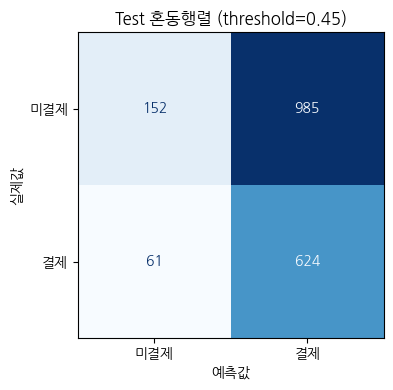

클래스별 상세 성능


,precision,recall,f1-score,support
미결제(0),0.7136,0.1337,0.2252,1137.0000
결제(1),0.3878,0.9109,0.5440,685.0000
accuracy,0.4259,0.4259,0.4259,0.4259
macro avg,0.5507,0.5223,0.3846,1822.0000
weighted avg,0.5911,0.4259,0.3451,1822.0000


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 주요 평가 지표
test_metrics_df = pd.DataFrame([{
    'threshold': best_threshold,
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred, zero_division=0),
    'recall': recall_score(y_test, y_test_pred, zero_division=0),
    'f1': f1_score(y_test, y_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_test_proba),
}]).round(4)

print('최종 Test 성능 지표')
display(test_metrics_df)

# 혼동행렬
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=['실제 미결제(0)', '실제 결제(1)'],
    columns=['예측 미결제(0)', '예측 결제(1)'],
)

print('혼동행렬')
display(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['미결제', '결제'])
disp.plot(values_format='d', cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Test 혼동행렬 (threshold={best_threshold:.2f})')
ax.set_xlabel('예측값')
ax.set_ylabel('실제값')
plt.tight_layout()
plt.show()

# 클래스별 상세 성능
report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=['미결제(0)', '결제(1)'],
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T.round(4)

print('클래스별 상세 성능')
display(report_df)


# 11. Feature Importance / Permutation Importance

최종 모델이 어떤 피처를 중요하게 사용했는지 본다. 살펴볼 중요도는 세 가지이다.

1. **XGBoost 기본 Feature Importance**
   모델 내부에서 피처가 얼마나 사용되었는지 본다.

2. **Gain 기준 Feature Importance**
   해당 피처 기준으로 고객을 나눴을 때 모델 성능 개선에 얼마나 기여했는지 본다.

3. **Permutation Importance**
   특정 피처 값을 섞었을 때 F1 Score가 얼마나 떨어지는지 확인한다. 성능 하락폭이 클수록 해당 피처가 예측에 중요하다고 볼 수 있다.

> Permutation Importance는 최종 Test 평가 이후 모델 해석을 위해 확인했다. 이 결과를 바탕으로 피처를 다시 선택하거나 모델을 수정하지 않았다.

XGBoost 기본 Feature Importance


,feature,xgb_importance
0,방문일수,0.624018
1,총출입횟수,0.189193
2,신청후첫방문일수,0.186790


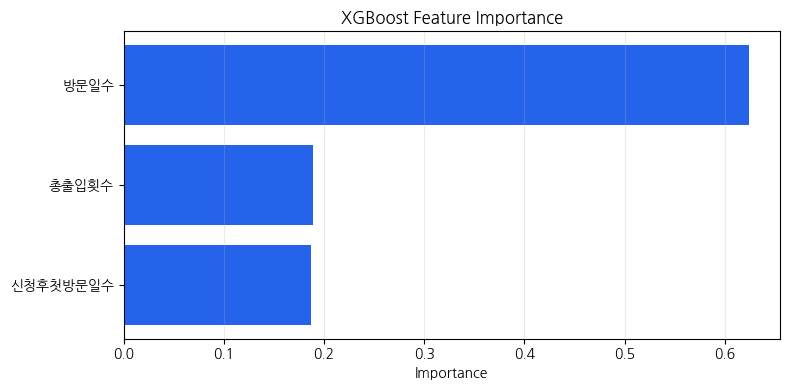

XGBoost Gain 기준 Feature Importance


,feature,gain_importance
0,방문일수,17.753948
1,총출입횟수,5.382726
2,신청후첫방문일수,5.314365


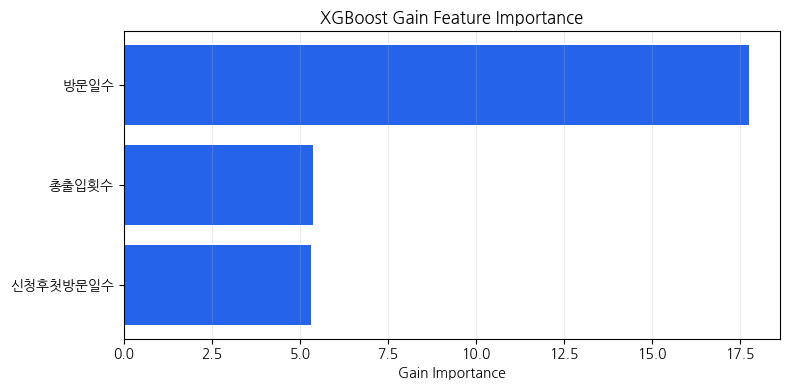

Permutation Importance


,feature,importance_mean,importance_std
0,방문일수,0.063854,0.012766
1,총출입횟수,-0.004456,0.007060
2,신청후첫방문일수,-0.009284,0.005282


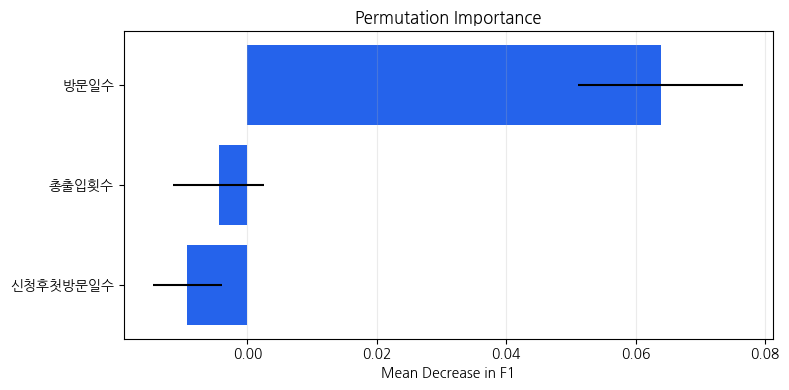

In [ ]:
from sklearn.inspection import permutation_importance

# 1. XGBoost 기본 Feature Importance
xgb_importance_df = pd.DataFrame({
    'feature': best_features,
    'xgb_importance': final_model.feature_importances_,
}).sort_values('xgb_importance', ascending=False)

print('XGBoost 기본 Feature Importance')
display(xgb_importance_df)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = xgb_importance_df.sort_values('xgb_importance', ascending=True)
ax.barh(plot_df['feature'], plot_df['xgb_importance'], color=BLUE)
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# 2. Gain 기준 Feature Importance
booster = final_model.get_booster()
gain_score = booster.get_score(importance_type='gain')

gain_importance_df = pd.DataFrame({
    'feature': best_features,
    'gain_importance': [gain_score.get(feature, 0) for feature in best_features],
}).sort_values('gain_importance', ascending=False)

print('XGBoost Gain 기준 Feature Importance')
display(gain_importance_df)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = gain_importance_df.sort_values('gain_importance', ascending=True)
ax.barh(plot_df['feature'], plot_df['gain_importance'], color=BLUE)
ax.set_xlabel('Gain Importance')
ax.set_title('XGBoost Gain Feature Importance')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# 3. Permutation Importance
perm_result = permutation_importance(
    final_model,
    X_test_final,
    y_test,
    scoring='f1',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    'feature': best_features,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

print('Permutation Importance')
display(permutation_importance_df)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = permutation_importance_df.sort_values('importance_mean', ascending=True)
ax.barh(
    plot_df['feature'],
    plot_df['importance_mean'],
    xerr=plot_df['importance_std'],
    color=BLUE,
)
ax.set_xlabel('Mean Decrease in F1')
ax.set_title('Permutation Importance')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


# 12. 모델 오류 분석: False Positive 중심 성능 진단

앞선 단계에서는 최종 모델의 Test 성능과 피처 중요도를 확인하였다. 이번 단계에서는 성능 지표만으로는 확인하기 어려운 **오분류 구조**를 추가로 점검한다.

특히 현재 모델은 결제 가능성이 있는 고객을 폭넓게 잡는 방향으로 threshold를 선택했기 때문에 Recall은 높지만 실제 미결제자를 결제자로 예측하는 **FP(False Positive)** 가 발생할 수 있다. FP는 리마케팅, 상담, 프로모션 대상 선정에서 불필요한 운영 비용을 만들 수 있으므로 별도로 확인할 필요가 있다.

> 이 분석은 최종 Test 예측값인 `X_test_final`, `y_test`, `y_test_pred`, `y_test_proba`, `best_features`, `best_threshold`가 생성된 이후 실행한다.

## 12-1. 오류 분석 기준

혼동행렬의 예측 결과를 TP, TN, FP, FN 네 그룹으로 나누어 비교한다.

| 구분 | 의미 | 해석 관점 |
|---|---|---|
| TP | 실제 결제자를 결제자로 예측 | 모델이 잘 잡아낸 결제 고객 |
| TN | 실제 미결제자를 미결제자로 예측 | 모델이 잘 제외한 미결제 고객 |
| FP | 실제 미결제자를 결제자로 예측 | 결제 가능성이 높아 보였지만 실제로는 미결제한 고객 |
| FN | 실제 결제자를 미결제자로 예측 | 모델이 놓친 결제 고객 |

이번 오류 분석은 FP를 중심으로 다음 네 가지를 따져본다.

1. FP 고객은 TP 고객과 행동 특성이 유사한가?
2. FP는 threshold 근처의 애매한 예측인가, 아니면 높은 확률로 잘못 예측된 사례인가?
3. threshold 조정만으로 Precision을 개선할 수 있는가?
4. 현재 모델의 한계가 threshold 문제인지, 피처 구분력 문제인지 확인할 수 있는가?

## 12-2. FP 중심 오류 분석 데이터 생성

Test 데이터의 실제값, 예측값, 예측 확률을 하나의 데이터프레임으로 결합한 뒤 혼동행렬 기준에 따라 TP, TN, FP, FN 그룹을 분리한다.

이렇게 그룹을 나누면 단순히 F1, Recall, Precision만 보는 것보다 **모델이 어떤 고객 유형을 헷갈려 하는지** 구체적으로 확인할 수 있다.

In [ ]:
test_result = X_test_final.copy()

test_result['actual'] = y_test.values
test_result['pred'] = y_test_pred
test_result['prob'] = y_test_proba

FP = test_result[(test_result['actual'] == 0) & (test_result['pred'] == 1)]
TN = test_result[(test_result['actual'] == 0) & (test_result['pred'] == 0)]
TP = test_result[(test_result['actual'] == 1) & (test_result['pred'] == 1)]
FN = test_result[(test_result['actual'] == 1) & (test_result['pred'] == 0)]

print('FP:', FP.shape)
print('TN:', TN.shape)
print('TP:', TP.shape)
print('FN:', FN.shape)


FP: (985, 6)
TN: (152, 6)
TP: (624, 6)
FN: (61, 6)


## 12-3. 그룹별 평균 비교

각 그룹의 최종 피처 평균을 비교해 오분류된 고객의 행동 특성을 본다.

방문일수를 뺀 나머지 피처에서는 FP와 TP의 평균값이 유사했다. 현재 모델이 사용하는 피처만으로는 **실제 결제 고객과 결제처럼 보이는 미결제 고객을 구분하기 어렵다**고 해석할 수 있다.

In [ ]:
compare_mean = pd.concat([
    FP[best_features].mean().rename('FP'),
    TN[best_features].mean().rename('TN'),
    TP[best_features].mean().rename('TP'),
    FN[best_features].mean().rename('FN')
], axis=1)

display(compare_mean.round(3))


,FP,TN,TP,FN
방문일수,0.781,1.013,0.989,1.049
총출입횟수,6.804,8.487,6.298,10.164
신청후첫방문일수,0.245,0.224,0.252,0.410


## 12-4. 그룹별 중앙값 비교

평균은 일부 극단값의 영향을 받을 수 있으므로 중앙값도 함께 확인한다.

모든 피처에서 FP와 TP의 중앙값도 차이가 없었기 때문에 두 그룹의 유의미한 차이를 확인하기 어려웠다.

In [ ]:
compare_median = pd.concat([
    FP[best_features].median().rename('FP'),
    TN[best_features].median().rename('TN'),
    TP[best_features].median().rename('TP'),
    FN[best_features].median().rename('FN')
], axis=1)

display(compare_median.round(3))


,FP,TN,TP,FN
방문일수,1.0,1.0,1.0,1.0
총출입횟수,4.0,6.0,4.0,7.0
신청후첫방문일수,1.0,0.0,1.0,0.0


## 12-5. 최종 피처 분포 비교

평균과 중앙값만으로는 각 그룹의 전체 분포를 확인하기 어렵다. 따라서 Boxplot을 사용해 그룹별 피처 분포를 비교한다.

Boxplot에서는 중앙값과 사분위수 범위, 이상치, 그룹 간 분포 겹침 정도를 확인했다.

FP의 분포가 TP와 크게 겹쳤기 때문에 모델이 FP를 결제자로 예측한 이유를 어느 정도 설명할 수 있었다.

In [ ]:
plot_df = pd.concat([
    FP.assign(group='FP'),
    TN.assign(group='TN'),
    TP.assign(group='TP'),
    FN.assign(group='FN')
])

plot_df['group'] = pd.Categorical(
    plot_df['group'],
    categories=['TN', 'FP', 'FN', 'TP'],
    ordered=True
)


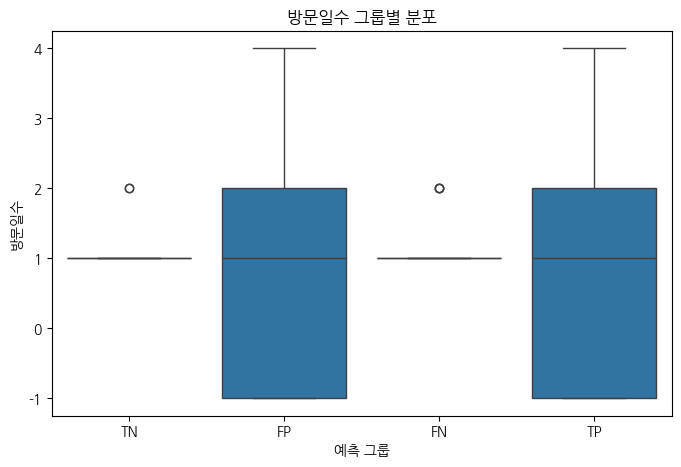

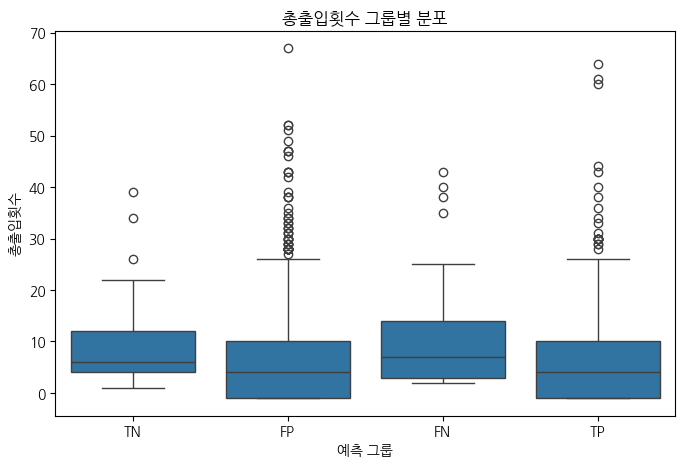

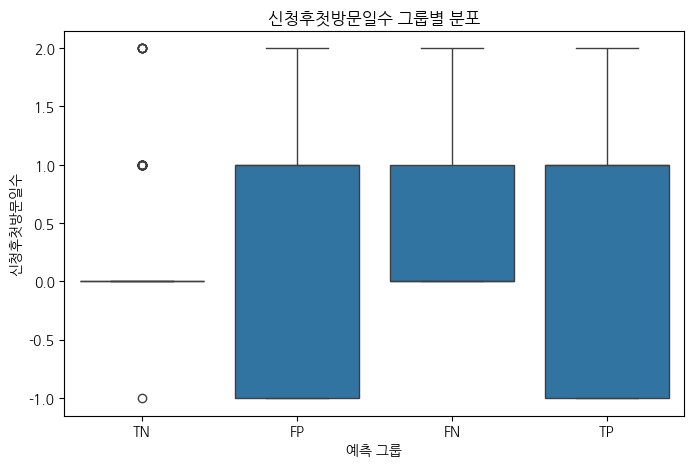

In [ ]:
for col in best_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=plot_df,
        x='group',
        y=col
    )

    plt.title(f'{col} 그룹별 분포')
    plt.xlabel('예측 그룹')
    plt.ylabel(col)
    plt.show()


## 12-6. FP와 TP 직접 비교

Precision이 낮아지는 가장 직접적인 원인은 FP이다. 실제 결제 고객인 TP와, 실제로는 미결제자인데 모델이 결제자로 예측한 FP를 직접 비교했다.

방문일 수 평균을 빼면 두 그룹의 평균과 중앙값이 모두 유사하게 나왔다. 현재 최종 피처만으로는 두 집단의 행동 차이를 충분히 구분하기 어렵다고 볼 수 있다.

In [ ]:
fp_tp_df = pd.concat([
    FP.assign(group='FP'),
    TP.assign(group='TP')
])

compare_fp_tp = pd.concat([
    FP[best_features].mean().rename('FP_mean'),
    TP[best_features].mean().rename('TP_mean'),
    FP[best_features].median().rename('FP_median'),
    TP[best_features].median().rename('TP_median')
], axis=1)

display(compare_fp_tp.round(3))


,FP_mean,TP_mean,FP_median,TP_median
방문일수,0.781,0.989,1.0,1.0
총출입횟수,6.804,6.298,4.0,4.0
신청후첫방문일수,0.245,0.252,1.0,1.0


## 12-7. FP 예측 확률 분포 확인

FP 고객의 예측 확률이 어느 구간에 위치하는지 확인한다.

FP가 threshold 근처에 많이 분포했기 때문에 모델이 애매한 고객을 결제자로 판단한 것으로 볼 수 있다.

따라서 추가적인 피처 설계보다는 threshold 조정을 통해 모델 성능을 향상시켰다.

,prob
count,985.000
mean,0.499
std,0.044
min,0.451
25%,0.470
50%,0.470
75%,0.525
max,0.785


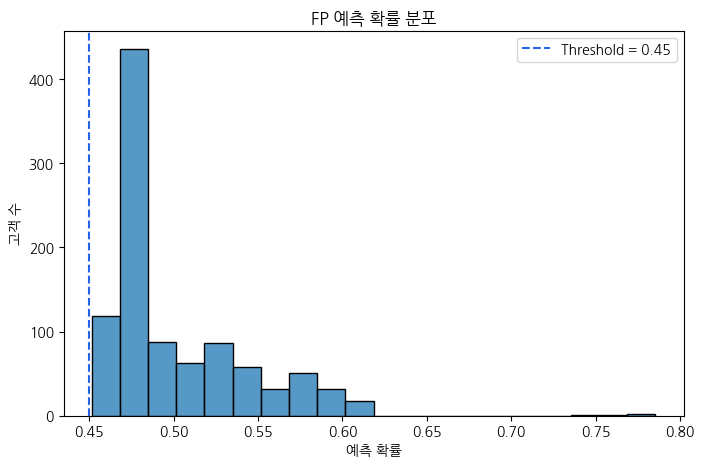

In [ ]:
display(FP['prob'].describe().round(3))

plt.figure(figsize=(8, 5))

sns.histplot(
    data=FP,
    x='prob',
    bins=20
)

plt.axvline(best_threshold, color=BLUE, linestyle='--', label=f'Threshold = {best_threshold:.2f}')
plt.title('FP 예측 확률 분포')
plt.xlabel('예측 확률')
plt.ylabel('고객 수')
plt.legend()
plt.show()


## 12-8. Threshold 부근 FP 비율 확인

FP 중 현재 threshold 근처에 위치한 비율을 계산한다. 여기서는 `best_threshold` 이상, `best_threshold + 0.1` 미만에 해당하는 FP를 threshold 부근의 사례로 정의한다.

이 비율이 높게 나와서 threshold를 소폭 높이는 방식으로 FP를 줄이고 Precision을 일부 개선하는 방향을 택했다.

In [ ]:
near_threshold_fp = FP[
    (FP['prob'] >= best_threshold) &
    (FP['prob'] < best_threshold + 0.1)
]

print('전체 FP 수:', len(FP))
print('threshold 근처 FP 수:', len(near_threshold_fp))

if len(FP) > 0:
    print('비율:', round(len(near_threshold_fp) / len(FP), 3))
else:
    print('비율: FP가 없어 계산하지 않음')


전체 FP 수: 985
threshold 근처 FP 수: 848
비율: 0.861


## 12-9. Threshold 조정 실험

현재 threshold 주변 구간에서 threshold를 변경하며 성능 변화를 확인한다.

| 지표 | 의미 |
|---|---|
| Accuracy | 전체 예측 중 맞춘 비율 |
| Precision | 결제로 예측한 고객 중 실제 결제자의 비율 |
| Recall | 실제 결제자 중 모델이 결제로 잡아낸 비율 |
| F1 | Precision과 Recall의 균형 지표 |

이번 모델은 결제 가능성이 있는 고객을 넓게 잡는 것이 중요하므로 Recall을 크게 낮추지 않으면서 F1이 개선되는 threshold가 있는지 본다.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in np.arange(0.45, 0.71, 0.01):

    y_pred = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        'threshold': round(threshold, 2),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    })

threshold_result_df = pd.DataFrame(threshold_results)

display(threshold_result_df)


,threshold,accuracy,precision,recall,f1
0,0.45,0.425906,0.387819,0.910949,0.544028
1,0.46,0.442920,0.393822,0.893431,0.546673
2,0.47,0.473106,0.404580,0.851095,0.548448
3,0.48,0.569704,0.434954,0.483212,0.457815
4,0.49,0.579034,0.444293,0.477372,0.460239
5,0.50,0.594402,0.457680,0.426277,0.441421
6,0.51,0.606476,0.472881,0.407299,0.437647
7,0.52,0.610318,0.476636,0.372263,0.418033
8,0.53,0.625686,0.503667,0.300730,0.376600
9,0.54,0.630077,0.516035,0.258394,0.344358


### 12-9-1. F1 기준 최적 Threshold 확인

아래 코드는 탐색한 threshold 중 F1 점수가 가장 높은 지점을 확인한다. 단, 최종 threshold를 다시 선택할 때는 F1만 볼 것이 아니라 프로젝트 목적상 Recall과 Precision의 trade-off도 함께 고려해야 한다.

In [ ]:
best = threshold_result_df.sort_values('f1', ascending=False).iloc[0]

display(best.to_frame().T)


,threshold,accuracy,precision,recall,f1
2,0.47,0.473106,0.40458,0.851095,0.548448


> 앞선 최종 모델 평가에서는 threshold 0.45 기준으로 다음과 같은 성능이 확인되었다.
>
> | threshold | accuracy | precision | recall | f1 | roc_auc |
> |---:|---:|---:|---:|---:|---:|
> | 0.45 | 0.4259 | 0.3878 | 0.9109 | 0.5440 | 0.5862 |
>
> threshold를 높이면 일반적으로 Precision은 올라가고 Recall은 낮아진다. FP를 줄이는 효과와 결제 고객을 놓치는 FN 증가 가능성을 함께 확인해야 한다.

### 12-9-2. Threshold 0.45와 0.47 비교

기존 기준 threshold인 0.45와, F1 기준으로 더 나은 후보로 확인된 0.47을 비교한다.

이 비교를 통해 threshold 조정이 실제로 어느 정도의 성능 개선을 만드는지 확인한다. 성능 개선 폭이 작다면 현재 모델의 한계는 threshold보다 피처의 구분력에 있을 가능성이 높다.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

thresholds = [0.45, 0.47]

result_list = []

for threshold in thresholds:
    y_pred = (y_test_proba >= threshold).astype(int)

    result_list.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_test_proba)
    })

threshold_compare_df = pd.DataFrame(result_list)

print('Threshold별 성능 비교')
display(threshold_compare_df.round(4))


Threshold별 성능 비교


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.45,0.4259,0.3878,0.9109,0.5440,0.5862
1,0.47,0.4731,0.4046,0.8511,0.5484,0.5862


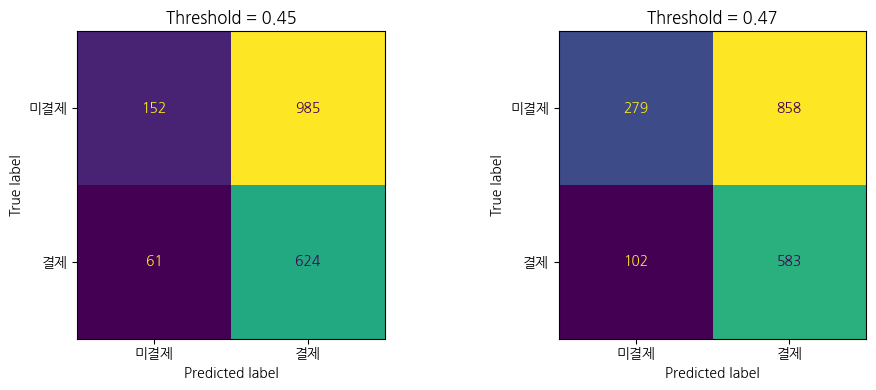

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, threshold in zip(axes, thresholds):

    y_pred = (y_test_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['미결제', '결제']
    )

    disp.plot(
        ax=ax,
        values_format='d',
        colorbar=False
    )

    ax.set_title(f'Threshold = {threshold}')

plt.tight_layout()
plt.show()


## 12-10. 오류 분석 결과 요약 및 한계점

FP와 TP의 최종 피처 분포가 유사한 것으로 보아 현재 모델은 결제 고객과 결제처럼 행동한 미결제 고객을 명확하게 구분하기 어렵다고 볼 수 있다.

또한 FP가 threshold 부근에 일부 집중되어 있어 threshold 조정으로 Precision 소폭 개선을 시도했지만 그만큼 Recall도 감소하였다. 결제 가능 고객을 놓치지 않는 것이 중요한 상황에서는 과도한 threshold 상향이 적절하지 않다고 생각되었다.

종합하면 현재 모델의 한계는 단순한 threshold 문제라기보다 **피처 구분력의 한계**에 가깝다. 향후 성능 개선을 위해서는 다음과 같은 추가 피처 엔지니어링이 필요하다.

- 방문 시간대 또는 요일 패턴
- 체류시간의 안정성 또는 변동성
- 3일 체험 기간 내 재방문 간격
- 신청 후 첫 방문까지의 속도 외에 방문 이후 행동 강도
- 지점별 면적, 혼잡도, 입지 특성
- 상담 또는 프로모션 접촉 여부

이 분석을 통해 최종 모델은 결제 가능성이 있는 고객을 넓게 담아내는 데는 의미가 있으나, 결제 고객과 비슷하게 행동하는 미결제 고객까지 함께 포함된다는 한계가 있음을 확인하였다.

현재 모델은 결제할 가능성이 있는 고객을 최대한 놓치지 않고 찾아내는 데 초점이 맞춰져 있어 이 모델의 예측만으로 결제 여부를 바로 판단하기보다는 영업이나 프로모션을 진행할 고객을 먼저 걸러내는 용도로 활용하는 것이 더 적절하다.

# 13. Streamlit 배포용 파일 저장

최종 모델을 Streamlit에서 사용하기 위해 필요한 파일을 저장한다.

저장 파일은 다음과 같다.

- `xgb_payment_model.pkl`: 최종 XGBoost 모델
- `feature_names.pkl`: 최종 피처 리스트
- `best_threshold.pkl`: 최종 threshold
- `feature_data.pkl`: Streamlit의 데이터 소개 및 결과 섹션에서 사용할 유저 단위 feature 데이터

In [ ]:
import joblib

joblib.dump(final_model, 'xgb_payment_model.pkl')
joblib.dump(best_features, 'feature_names.pkl')
joblib.dump(best_threshold, 'best_threshold.pkl')
joblib.dump(feature_df, 'feature_data.pkl')

print('Streamlit 배포용 파일 저장 완료')
print('- xgb_payment_model.pkl')
print('- feature_names.pkl')
print('- best_threshold.pkl')
print('- feature_data.pkl')


Streamlit 배포용 파일 저장 완료
- xgb_payment_model.pkl
- feature_names.pkl
- best_threshold.pkl
- feature_data.pkl


# Streamlit 파일 배포
https://payment-conversion-prediction-kfmzlsbdapywsfresbxfkm.streamlit.app/